# Exercise 4.A Introduction to Linear Regression

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


## Lab 1
### Running a sample script


Model trained successfully.

Slope (coefficient): 0.69
Intercept: 1.77
Predictions: [3.14285714]


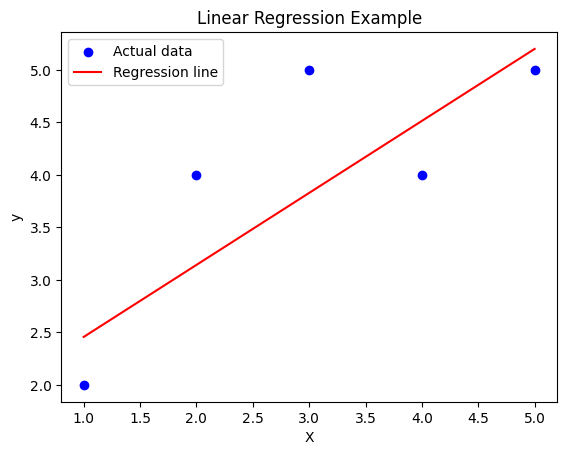

In [9]:
X = np.array([1, 2, 3, 4, 5]).reshape(-1,1)
y = np.array([2, 4, 5, 4, 5])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully.")
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')

y_pred = model.predict(X_test)
print("Predictions:", y_pred)

plt.scatter(X, y, color="blue", label="Actual data")
plt.plot(X, model.predict(X), color="red", label="Regression line")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Example")
plt.legend()
plt.show()


In [11]:
print("Actual scores:   ", y_test.tolist())
print("Predicted scores:", y_pred.round(1).tolist())


Actual scores:    [4]
Predicted scores: [3.1]


In [13]:
r_squared = model.score(X_test, y_test)
print(f'R2 score: {r_squared:.3f}')

R2 score: nan


/opt/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


The R² score could not be meaningfully calculated here because the test set contains fewer than two samples. R² measures how much of the variation in the target variable is explained by the model, but with only one test point there is not enough variation to evaluate. This means the result is undefined (`nan`) and does not give a useful measure of model fit in this example.


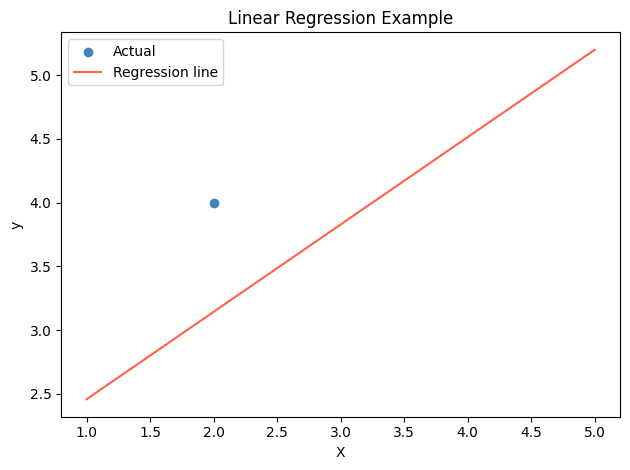

In [17]:
# Scatter plot: actual test data points
plt.scatter(X_test, y_test, color='steelblue', label='Actual', zorder=3)

# Line: model predictions across the full range of X
x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(x_range)
plt.plot(x_range, y_line, color='tomato', label='Regression line')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Example')
plt.legend()
plt.tight_layout()
plt.show()


The scatter plot shows the actual test data point and the fitted regression line. In this example, there is only one test point, so it is hard to judge the overall fit visually. The point appears somewhat close to the regression line, but the dataset is too small to make a strong conclusion about model performance.


## Lab 2
### Building your own model


In [18]:
ad_data = {
    "monthly_ad_spend": [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000,
                         5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],
    "monthly_revenue": [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800, 12400, 13100,
                        14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100, 23800]
}

df_ads = pd.DataFrame(ad_data)
df_ads


,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [19]:
X2 = df_ads[["monthly_ad_spend"]]
y2 = df_ads["monthly_revenue"]

print("Shape of X2:", X2.shape)
print("Shape of y2:", y2.shape)

Shape of X2: (20, 1)
Shape of y2: (20,)


In [22]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [24]:
model2 = LinearRegression()
model2.fit(X2_train,y2_train)
print("Model trained successfully.")

Model trained successfully.


In [25]:
print("Model trained successfully.")

Model trained successfully.


In [26]:
print(f"Slope: {model2.coef_[0]:.2f}")
print(f"Intercept: {model2.intercept_:.2f}")

# Interpretation:
# For each additional 1 dollar in monthly ad spend,
# the predicted monthly revenue increases by about [slope] dollars.


Slope: 1.96
Intercept: 3625.89


### Making predictions and evaluating the model


In [27]:
y2_pred = model2.predict(X2_test)

print("Actual values:   ", y2_test.tolist())
print("Predicted values:", y2_pred.round(2).tolist())


Actual values:    [4200, 21500, 19400, 5100]
Predicted values: [4603.85, 21229.03, 19273.13, 5581.8]


In [28]:
r2_model2 = model2.score(X2_test, y2_test)
print(f"R² score: {r2_model2:.3f}")


R² score: 0.998


The R² score shows how much of the variation in monthly revenue is explained by monthly ad spend. An R² score of 0.998 means the model fits the data extremely well. This suggests that about 99.8% of the variation in revenue is explained by ad spend, so the linear regression model appears to be a very strong fit.


### Visualizing the results

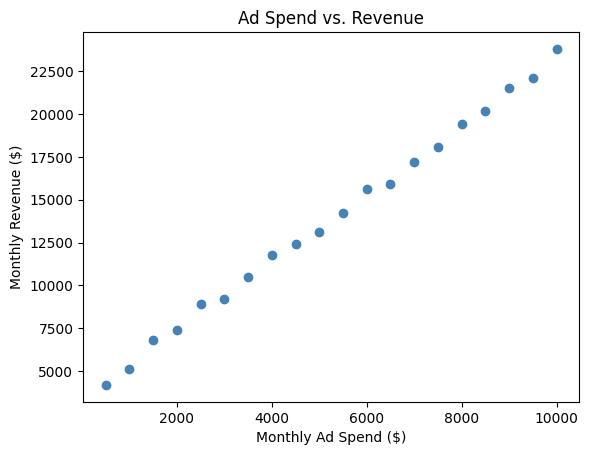

In [29]:
plt.scatter(X2, y2, color="steelblue")
plt.xlabel("Monthly Ad Spend ($)")
plt.ylabel("Monthly Revenue ($)")
plt.title("Ad Spend vs. Revenue")
plt.show()


/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


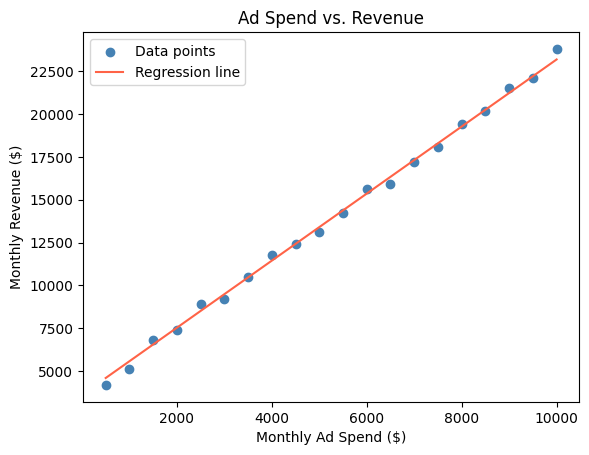

In [33]:
plt.scatter(X2, y2, color="steelblue", label="Data points")

x_line = np.linspace(X2["monthly_ad_spend"].min(), X2["monthly_ad_spend"].max(), 100).reshape(-1, 1)
y_line = model2.predict(x_line)

plt.plot(x_line, y_line, color="tomato", label="Regression line")
plt.xlabel("Monthly Ad Spend ($)")
plt.ylabel("Monthly Revenue ($)")
plt.title("Ad Spend vs. Revenue")
plt.legend()
plt.show()
